<a href="https://colab.research.google.com/github/kateeeberry/global-suicide-data-insights/blob/main/ProjectX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# --- ENVIRONMENT SETUP ---

In [79]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
%cd /content/drive/MyDrive/Project X

/content/drive/MyDrive/Project X


In [81]:
# Load the raw WHO suicide statistics dataset
df = pd.read_csv("who_suicide_statistics.csv")

In [82]:
# Drop missing values to ensure data consistency
df = df.dropna()

In [83]:
# Calculate the standardized Suicide Rate per 100,000 population
df.loc[:, "Suicide Rate"] = (df["suicides_no"] / df["population"]) * 100000
df.loc[:, "Suicide Rate"] = df["Suicide Rate"].fillna(0)

In [84]:
# Filter the data to focus on the historical range from 1979 to 2015
df_cleaned = df[df["year"] < 2016].copy()

# --- DATA PREPARATION: GLOBAL GENDER TRENDS ---

In [85]:
# Group by sex and year, then pivot to separate male and female counts
grouped_mixed_sex = df_cleaned.groupby(["sex", "year"])["suicides_no"].sum().reset_index()
global_sex_trend = grouped_mixed_sex.pivot(index="year", columns="sex", values="suicides_no")
global_sex_trend.columns.name = None

# --- VISUALIZATION: LINE PLOT ---

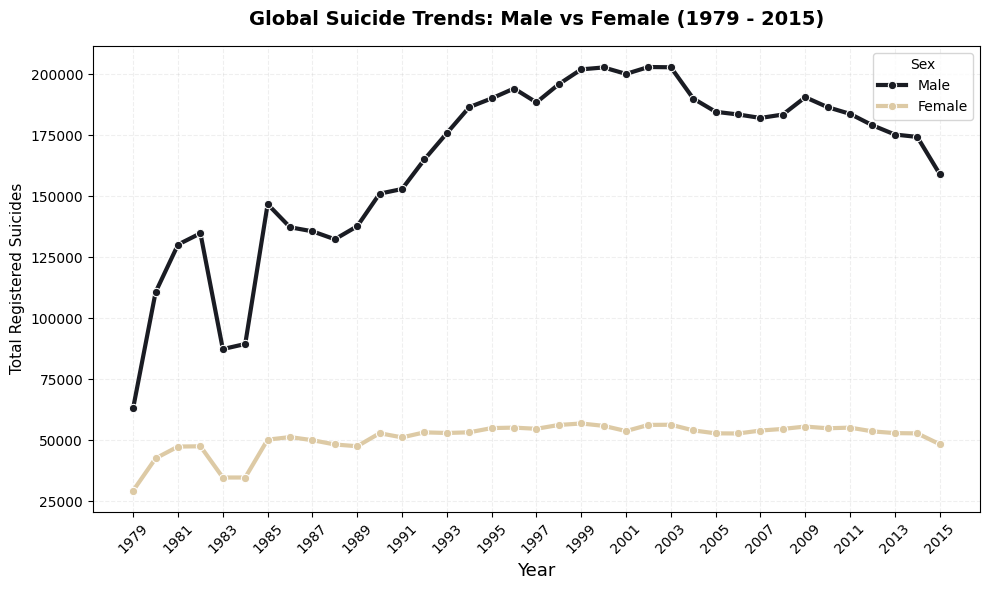

In [86]:
plt.figure(figsize=(10, 6))

# Plot absolute suicide counts for males
sns.lineplot(
    data=global_sex_trend,
    x="year",
    y="male",
    label="Male", color="#1a1c23", linewidth=3, marker="o")

# Plot absolute suicide counts for females
sns.lineplot(
    data=global_sex_trend,
    x="year",
    y="female",
    label="Female", color="#ddcaa5", linewidth=3, marker="o")

# Chart styling and labels
plt.title("Global Suicide Trends: Male vs Female (1979 - 2015)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Total Registered Suicides", fontsize=11)
plt.grid(axis="both", linestyle="--", alpha=0.2)
plt.legend(title="Sex")

# Format X-axis ticks to avoid overlapping text
years = sorted(global_sex_trend.index.unique())
plt.xticks(ticks=years[::2], labels=years[::2], rotation=45)

plt.tight_layout()
plt.show()


# --- DATA PREPARATION: TOP 10 COUNTRIES BY GENDER ---

In [87]:
# Calculate the mean suicide rate per country for males and get the top 10
male_top10 = (
    df_cleaned[df_cleaned["sex"] == "male"]
    .groupby("country")["Suicide Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
# Calculate the mean suicide rate per country for females and get the top 10
female_top10 = (
    df_cleaned[df_cleaned["sex"] == "female"]
    .groupby("country")["Suicide Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# --- VISUALIZATION: TOP 10 COUNTRIES BAR PLOTS ---

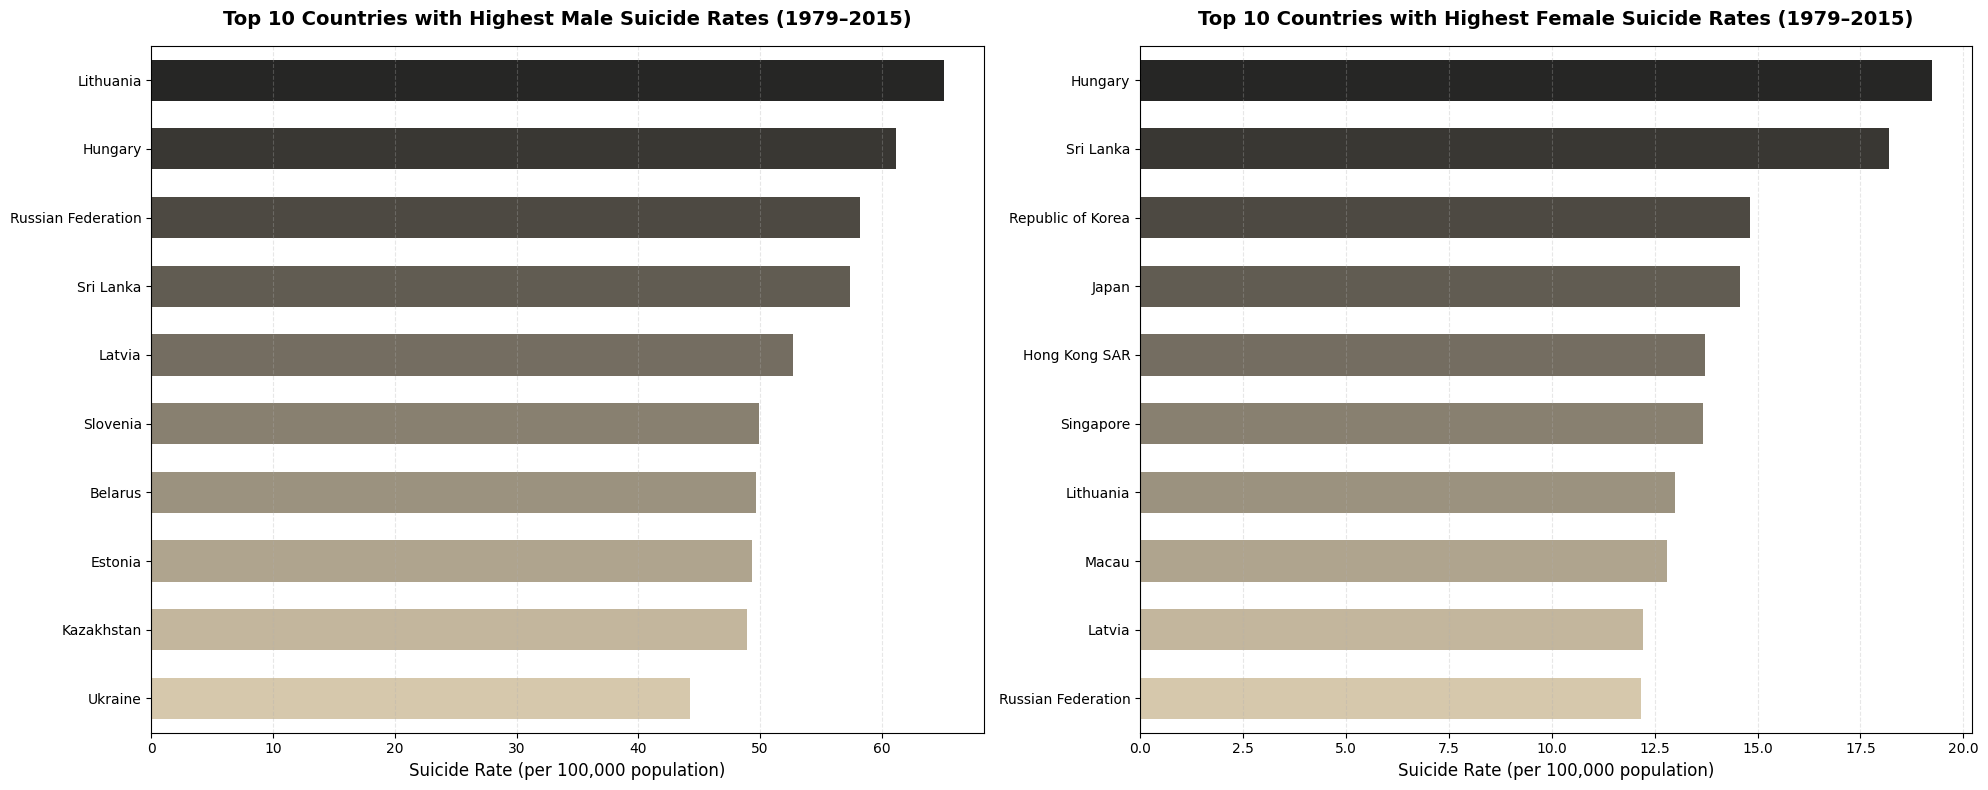

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=False)

# Horizontal barplot for top 10 male suicide rates
sns.barplot(
    data=male_top10,
    x="Suicide Rate",
    y="country",
    ax=axes[0],
    hue="country",
    palette="dark:#ddcaa5",
    legend=False,
    width=0.6
    )
axes[0].set_title("Top 10 Countries with Highest Male Suicide Rates (1979–2015)", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Suicide Rate (per 100,000 population)", fontsize=12)
axes[0].set_ylabel("", fontsize=12)
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

# Horizontal barplot for top 10 female suicide rates
sns.barplot(
    data=female_top10,
    x="Suicide Rate",
    y="country",
    ax=axes[1],
    hue="country",
    palette="dark:#ddcaa5",
    legend=False,
    width=0.6
    )
axes[1].set_title("Top 10 Countries with Highest Female Suicide Rates (1979–2015)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Suicide Rate (per 100,000 population)", fontsize=12)
axes[1].set_ylabel("", fontsize=12)
axes[1].grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# --- DATA PREPARATION: AGE GROUP ANALYSIS ---

In [89]:
# Calculate the mean suicide rate grouped by sex and age
age_gender_analysis = df_cleaned.groupby(["sex", "age"])["Suicide Rate"].mean().reset_index().sort_values(by="age", ascending=True)

In [90]:
# Define chronological order for age groups and enforce categorical sorting
age_order = ["5-14 years", "15-24 years", "25-34 years", "35-54 years", "55-74 years", "75+ years"]
age_gender_analysis["age"] = pd.Categorical(age_gender_analysis["age"], categories=age_order, ordered=True)
age_gender_analysis = age_gender_analysis.sort_values(by=["sex", "age"])
print(age_gender_analysis)

       sex          age  Suicide Rate
3   female   5-14 years      0.460720
0   female  15-24 years      4.382068
1   female  25-34 years      4.771631
2   female  35-54 years      6.240414
4   female  55-74 years      7.757289
5   female    75+ years     10.896905
9     male   5-14 years      0.800870
6     male  15-24 years     13.242165
7     male  25-34 years     20.099559
8     male  35-54 years     24.594604
10    male  55-74 years     25.864050
11    male    75+ years     39.202633


# --- VISUALIZATION: AGE & GENDER COMPARISON ---

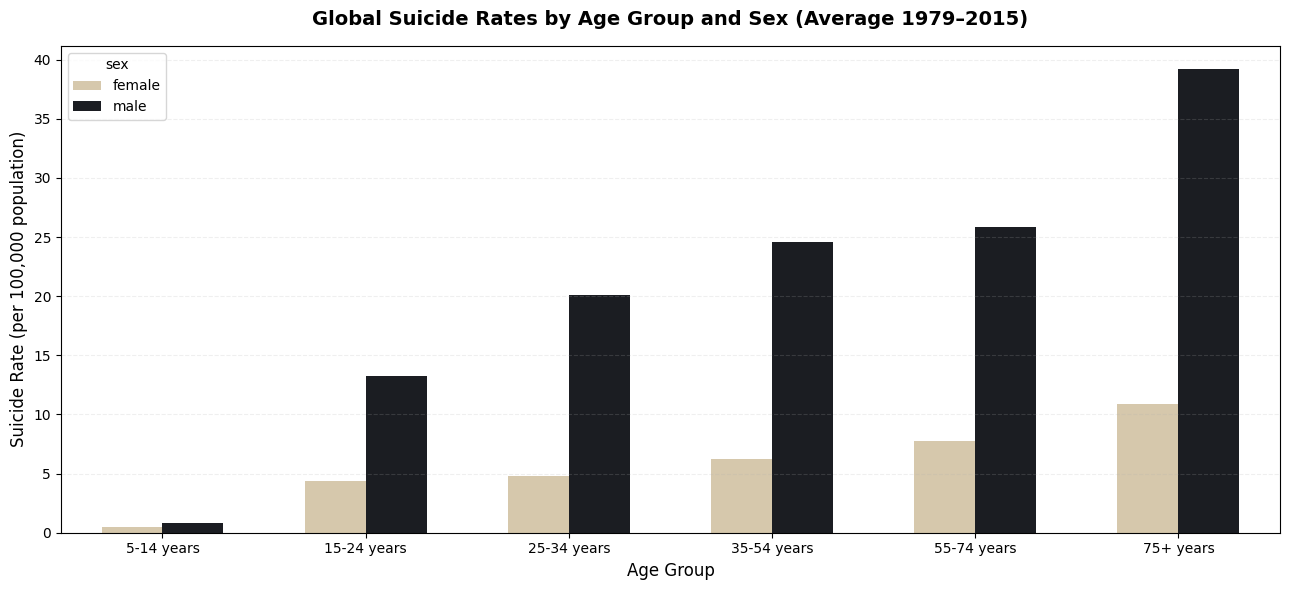

In [91]:
plt.figure(figsize=(13, 6))

# Grouped barplot comparing suicide rates across age brackets and genders
sns.barplot(
    data=age_gender_analysis,
    x="age",
    y="Suicide Rate",
    hue="sex",
    palette=["#ddcaa5", "#1a1c23"],
    width=0.6
)

plt.title("Global Suicide Rates by Age Group and Sex (Average 1979–2015)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Suicide Rate (per 100,000 population)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()

# --- DATA PREPARATION: PIE / DONUT CHARTS ---

In [92]:
# Aggregate total absolute suicide numbers by sex and age for distribution analysis
total_suicide = df_cleaned.groupby("sex")["suicides_no"].sum()
pie_data = df_cleaned.groupby(["sex", "age"])["suicides_no"].sum().reset_index()

In [93]:
# Define chronological order for age groups to ensure correct alignment in charts
age_order = ["5-14 years", "15-24 years", "25-34 years", "35-54 years", "55-74 years", "75+ years"]

In [94]:
# Filter and reindex male and female sub-datasets to follow the strict chronological age order
male_pie = pie_data[pie_data["sex"] == "male"].set_index("age").reindex(age_order).reset_index()
female_pie = pie_data[pie_data["sex"] == "female"].set_index("age").reindex(age_order).reset_index()

# --- VISUALIZATION: STANDALONE DONUT CHARTS ---

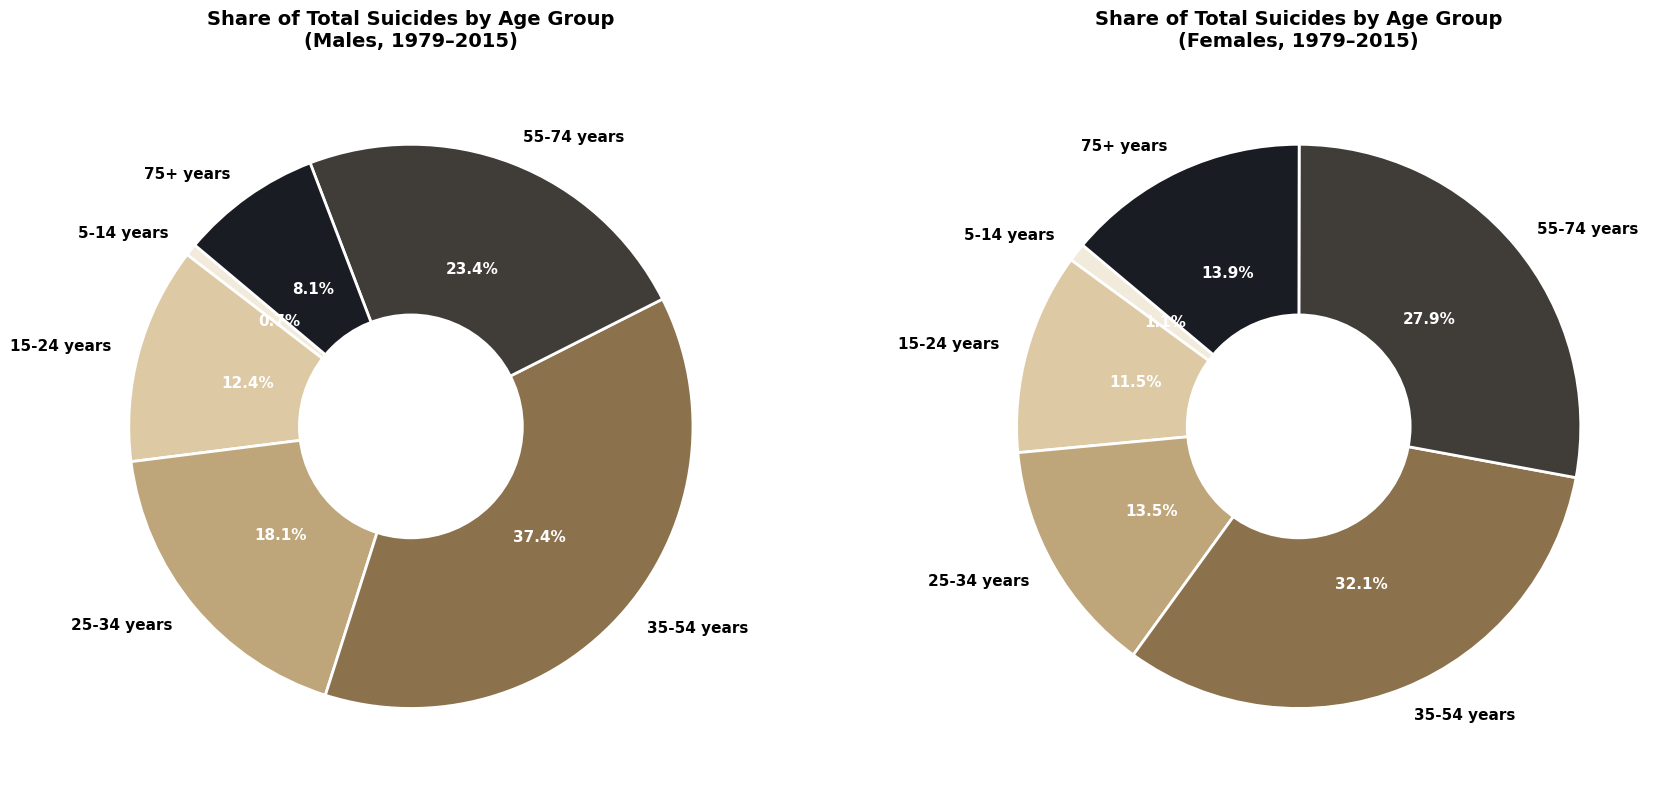

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Cohesive custom color palette representing 6 distinct age groups
colors = ["#f2ebdc", "#ddcaa5", "#bfa67a", "#8c714d", "#403d39", "#1a1c23"]

# --- Male Suicide Share Donut Chart ---
_, _, autotexts_male = axes[0].pie(
    male_pie["suicides_no"],
    labels=male_pie["age"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title("Share of Total Suicides by Age Group\n(Males, 1979–2015)", fontsize=14, fontweight="bold", pad=20)

for text in autotexts_male:
    text.set_color('white')

# Overlay a central white circle to generate the donut shape
centre_circle_male = plt.Circle((0,0), 0.40, fc="white")
axes[0].add_artist(centre_circle_male)


# --- Female Suicide Share Donut Chart ---
_, _, autotexts_female = axes[1].pie(
    female_pie["suicides_no"],
    labels=female_pie["age"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title("Share of Total Suicides by Age Group\n(Females, 1979–2015)", fontsize=14, fontweight="bold", pad=20)

for text in autotexts_female:
    text.set_color('white')

# Overlay a central white circle to generate the donut shape
centre_circle_female = plt.Circle((0,0), 0.40, fc="white")
axes[1].add_artist(centre_circle_female)


plt.tight_layout()
plt.show()

# --- DATA PREPARATION: CULTURAL & RELIGIOUS MAPPING ---

In [96]:
# Define a macro-level mapping to group countries by dominant religious/cultural backgrounds
religion_map = {
    # Orthodoxy
    'Russian Federation': 'Orthodoxy', 'Ukraine': 'Orthodoxy', 'Belarus': 'Orthodoxy',
    'Bulgaria': 'Orthodoxy', 'Romania': 'Orthodoxy', 'Georgia': 'Orthodoxy',

    # Islam
    'Kazakhstan': 'Islam', 'Kyrgyzstan': 'Islam', 'Turkmenistan': 'Islam',
    'Uzbekistan': 'Islam', 'Albania': 'Islam', 'Azerbaijan': 'Islam',
    'United Arab Emirates': 'Islam', 'Kuwait': 'Islam', 'Qatar': 'Islam',
    'Bahrain': 'Islam', 'Oman': 'Islam', 'Maldives': 'Islam',

    # Catholicism
    'Lithuania': 'Catholicism', 'Poland': 'Catholicism', 'Brazil': 'Catholicism',
    'France': 'Catholicism', 'Italy': 'Catholicism', 'Spain': 'Catholicism',
    'Colombia': 'Catholicism', 'Mexico': 'Catholicism', 'Hungary': 'Catholicism/Mixed',

    # Protestantism
    'United States of America': 'Protestantism/Mixed', 'United Kingdom': 'Protestantism/Mixed',
    'Germany': 'Protestantism/Mixed', 'Sweden': 'Protestantism/Mixed', 'Norway': 'Protestantism/Mixed',

    # Eastern Traditions / Secularism
    'Japan': 'Eastern Religions / Secular', 'Republic of Korea': 'Eastern Religions / Secular',
    'Singapore': 'Eastern Religions / Secular', 'Hong Kong SAR': 'Eastern Religions / Secular',
    'Sri Lanka': 'Buddhism/Mixed'
}

In [97]:
# Apply mapping and categorize countries not explicitly defined as 'Other / Mixed'
df_cleaned.loc[:, 'religion'] = df_cleaned['country'].map(religion_map).fillna('Other / Mixed')
df_cleaned[['country', 'religion']].drop_duplicates().head(10)

,country,religion
24,Albania,Islam
720,Antigua and Barbuda,Other / Mixed
1056,Argentina,Other / Mixed
1500,Armenia,Other / Mixed
1920,Aruba,Other / Mixed
2160,Australia,Other / Mixed
2616,Austria,Other / Mixed
3060,Azerbaijan,Islam
3372,Bahamas,Other / Mixed
3708,Bahrain,Islam


In [98]:
# Aggregate data to find the mean suicide rate per cultural group and gender
religion_analysis = (
    df_cleaned.groupby(["religion", "sex"])["Suicide Rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# --- VISUALIZATION: CULTURAL BACKGROUND COMPARISON ---

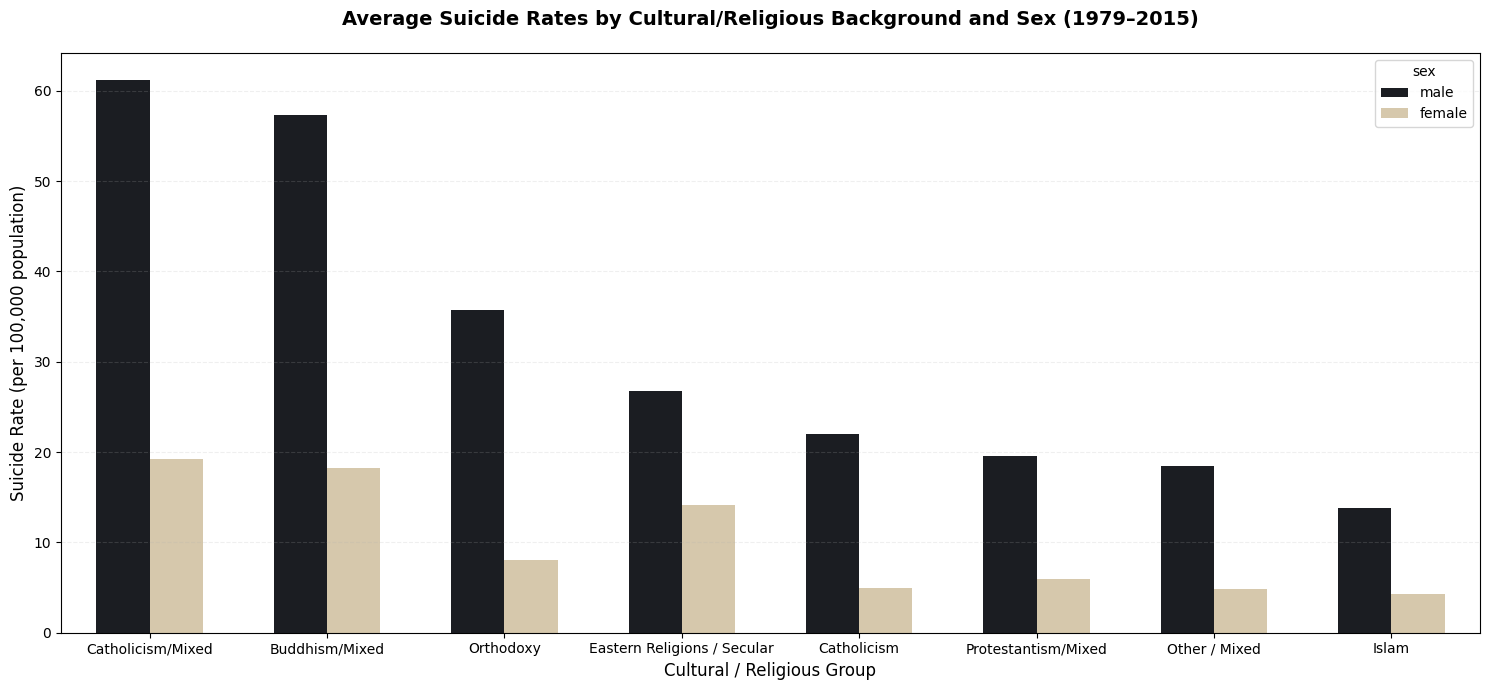

In [99]:
plt.figure(figsize=(15, 7))

# Grouped barplot evaluating suicide rates through a cultural/religious lens
sns.barplot(
    data=religion_analysis,
    x="religion",
    y="Suicide Rate",
    hue="sex",
    palette=["#1a1c23", "#ddcaa5"],
    width=0.6
)

plt.title("Average Suicide Rates by Cultural/Religious Background and Sex (1979–2015)", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Cultural / Religious Group", fontsize=12)
plt.ylabel("Suicide Rate (per 100,000 population)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()

# --- DASHBOARD GENERATION (4x2 GRID) ---

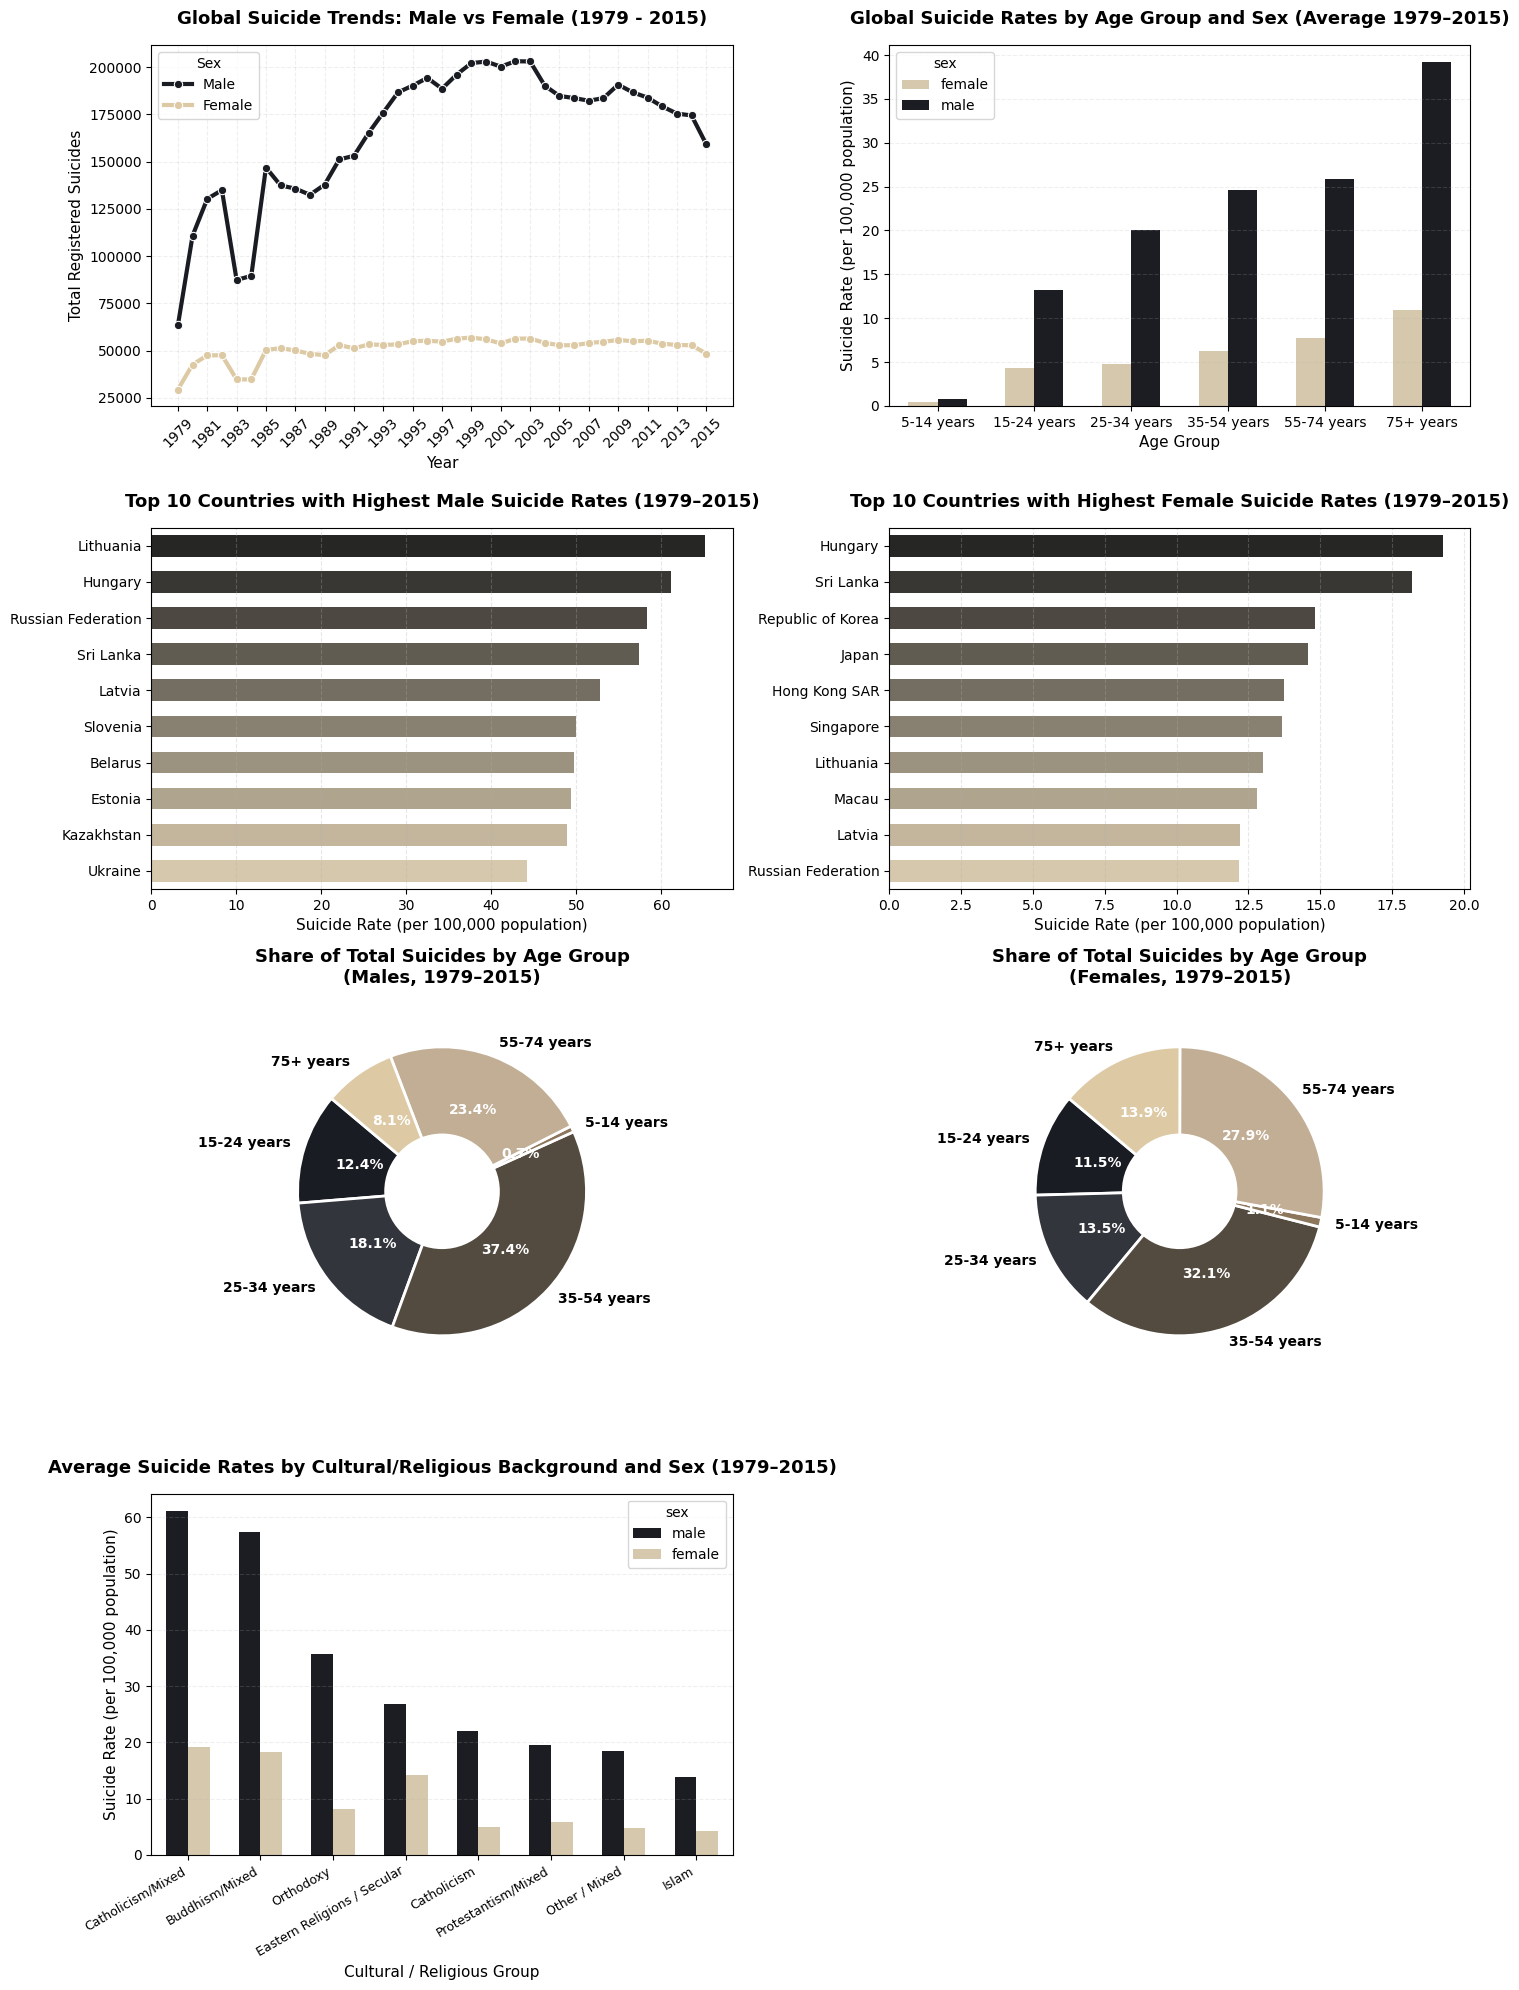

In [102]:
# Initialize a 4-row, 2-column subplot grid for a cohesive layout
fig, ax = plt.subplots(4, 2, figsize=(15, 20))

# ROW 1, LEFT [0, 0]: GLOBAL GENDER TRENDS (LINE PLOT)
sns.lineplot(
    data=global_sex_trend, x=global_sex_trend.index, y="male",
    label="Male", color="#1a1c23", linewidth=3, marker="o", ax=ax[0, 0]
)
sns.lineplot(
    data=global_sex_trend, x=global_sex_trend.index, y="female",
    label="Female", color="#ddcaa5", linewidth=3, marker="o", ax=ax[0, 0]
)
ax[0, 0].set_title("Global Suicide Trends: Male vs Female (1979 - 2015)", fontsize=13, fontweight="bold", pad=15)
ax[0, 0].set_xlabel("Year", fontsize=11)
ax[0, 0].set_ylabel("Total Registered Suicides", fontsize=11)
ax[0, 0].grid(axis="both", linestyle="--", alpha=0.2)
ax[0, 0].legend(title="Sex")

# Clean formatting for X-axis year ticks to avoid overlapping
years = sorted(global_sex_trend.index.unique())
ax[0, 0].set_xticks(years[::2])
ax[0, 0].set_xticklabels(years[::2], rotation=45)


# ROW 1, RIGHT [0, 1]: RATES BY AGE & SEX (GROUPED BAR CHART)
sns.barplot(
    data=age_gender_analysis, x="age", y="Suicide Rate", hue="sex",
    palette=["#ddcaa5", "#1a1c23"], width=0.6, ax=ax[0, 1]
)
ax[0, 1].set_title("Global Suicide Rates by Age Group and Sex (Average 1979–2015)", fontsize=13, fontweight="bold", pad=15)
ax[0, 1].set_xlabel("Age Group", fontsize=11)
ax[0, 1].set_ylabel("Suicide Rate (per 100,000 population)", fontsize=11)
ax[0, 1].grid(axis="y", linestyle="--", alpha=0.2)


# ROW 2, LEFT [1, 0]: TOP 10 COUNTRIES FOR MALES (HORIZONTAL BAR CHART)
sns.barplot(
    data=male_top10, x="Suicide Rate", y="country", hue="country",
    palette="dark:#ddcaa5", legend=False, width=0.6, ax=ax[1, 0]
)
ax[1, 0].set_title("Top 10 Countries with Highest Male Suicide Rates (1979–2015)", fontsize=13, fontweight="bold", pad=15)
ax[1, 0].set_xlabel("Suicide Rate (per 100,000 population)", fontsize=11)
ax[1, 0].set_ylabel("", fontsize=11)
ax[1, 0].grid(axis="x", linestyle="--", alpha=0.3)


# ROW 2, RIGHT [1, 1]: TOP 10 COUNTRIES FOR FEMALES (HORIZONTAL BAR CHART)
sns.barplot(
    data=female_top10, x="Suicide Rate", y="country", hue="country",
    palette="dark:#ddcaa5", legend=False, width=0.6, ax=ax[1, 1]
)
ax[1, 1].set_title("Top 10 Countries with Highest Female Suicide Rates (1979–2015)", fontsize=13, fontweight="bold", pad=15)
ax[1, 1].set_xlabel("Suicide Rate (per 100,000 population)", fontsize=11)
ax[1, 1].set_ylabel("", fontsize=11)
ax[1, 1].grid(axis="x", linestyle="--", alpha=0.3)


# ROW 3, LEFT [2, 0]: SHARE OF TOTAL SUICIDES - MALES (DONUT CHART)
male_pie = pie_data[pie_data["sex"] == "male"].sort_values(by="age")
colors_male = ["#1a1c23", "#33353d", "#534b40", "#8c765c", "#c2ae95", "#ddcaa5"]

_, _, autotexts_male = ax[2, 0].pie(
    male_pie["suicides_no"], labels=male_pie["age"], autopct="%1.1f%%", startangle=140,
    colors=colors_male, textprops={'fontsize': 10, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax[2, 0].set_title("Share of Total Suicides by Age Group\n(Males, 1979–2015)", fontsize=13, fontweight="bold", pad=20)

for text in autotexts_male:
    text.set_color('white')

# Cut out the center to transform the pie chart into a polished donut chart
centre_circle_male = plt.Circle((0,0), 0.40, fc="white")
ax[2, 0].add_artist(centre_circle_male)


# ROW 3, RIGHT [2, 1]: SHARE OF TOTAL SUICIDES - FEMALES (DONUT CHART)
female_pie = pie_data[pie_data["sex"] == "female"].sort_values(by="age")
colors_female = ["#1a1c23", "#33353d", "#534b40", "#8c765c", "#c2ae95", "#ddcaa5"]

_, _, autotexts_female = ax[2, 1].pie(
    female_pie["suicides_no"], labels=female_pie["age"], autopct="%1.1f%%", startangle=140,
    colors=colors_female, textprops={'fontsize': 10, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax[2, 1].set_title("Share of Total Suicides by Age Group\n(Females, 1979–2015)", fontsize=13, fontweight="bold", pad=20)

for text in autotexts_female:
    text.set_color('white')

centre_circle_female = plt.Circle((0,0), 0.40, fc="white")
ax[2, 1].add_artist(centre_circle_female)


# ROW 4, LEFT [3, 0]: RATES BY CULTURAL / RELIGIOUS BACKGROUND
# Note: Ensure 'religion_analysis' DataFrame is prepared before running this block
sns.barplot(
    data=religion_analysis, x="religion", y="Suicide Rate", hue="sex",
    palette=["#1a1c23", "#ddcaa5"], width=0.6, ax=ax[3, 0]
)
ax[3, 0].set_title("Average Suicide Rates by Cultural/Religious Background and Sex (1979–2015)", fontsize=13, fontweight="bold", pad=15)
ax[3, 0].set_xlabel("Cultural / Religious Group", fontsize=11)
ax[3, 0].set_ylabel("Suicide Rate (per 100,000 population)", fontsize=11)
ax[3, 0].grid(axis="y", linestyle="--", alpha=0.2)

# Fix X-axis labels alignment without causing Matplotlib UserWarnings
ax[3, 0].set_xticks(ax[3, 0].get_xticks())
ax[3, 0].set_xticklabels(ax[3, 0].get_xticklabels(), rotation=30, ha='right', fontsize=9)


# ROW 4, RIGHT [3, 1]: EMPTY AXIS CLEANUP
# Hide the unused subplot in the bottom right corner to keep the dashboard clean
ax[3, 1].axis('off')

# Final adjustments for tight packing and vertical spacing
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.show()
